In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
mlines = pyimport("matplotlib").lines

PyObject <module 'matplotlib.lines' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/matplotlib/lines.py'>

In [24]:
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"

bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"

Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"

In [5]:
qs22nc, plasmon22nc, confinements22nc = [x for x in eachcol(np.loadtxt("$bn22nc_dir/Wannier/Plasmon.txt"))];
qs33nc, plasmon33nc, confinements33nc = [x for x in eachcol(np.loadtxt("$bn33nc_dir/Wannier/Plasmon.txt"))];
qs44nc, plasmon44nc, confinements44nc = [x for x in eachcol(np.loadtxt("$bn44nc_dir/Wannier/Plasmon.txt"))];

In [8]:
qs22bc, plasmon22bc, confinements22bc = [x for x in eachcol(np.loadtxt("$bn22bc_dir/Wannier/Plasmon.txt"))];
qs33bc, plasmon33bc, confinements33bc = [x for x in eachcol(np.loadtxt("$bn33bc_dir/Wannier/Plasmon.txt"))];
qs44bc, plasmon44bc, confinements44bc = [x for x in eachcol(np.loadtxt("$bn44bc_dir/Wannier/Plasmon.txt"))];

In [10]:
omegas,  tau22nc = [x for x in eachcol(np.loadtxt("$bn22nc_dir/Plasmons/tau.txt"))];
_ , tau33nc = [x for x in eachcol(np.loadtxt("$bn33nc_dir/Plasmons/tau.txt"))];
_ , tau44nc = [x for x in eachcol(np.loadtxt("$bn44nc_dir/Plasmons/tau.txt"))];

In [27]:
_ , tau22bc = [x for x in eachcol(np.loadtxt("$bn22bc_dir/Plasmons/tau.txt"))];
_ , tau33bc = [x for x in eachcol(np.loadtxt("$bn33bc_dir/Plasmons/tau.txt"))];
_ , tau44bc = [x for x in eachcol(np.loadtxt("$bn44bc_dir/Plasmons/tau.txt"))];
tauAg = np.loadtxt("$Ag_dir/Ag_3D_tau.txt");

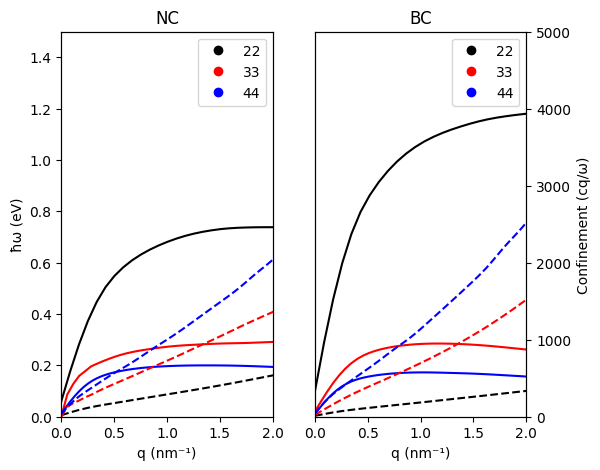

PyObject <matplotlib.legend.Legend object at 0x7f9b6e772880>

In [7]:
#Legend Properties
lab22 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black");
lab33 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red");
lab44 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="blue");

figure(figsize=(6, 5))
subplot(1, 2, 1)
ylim(0, 1.5)
ylabel("ħω (eV)")
plot(qs22nc*10, plasmon22nc, color="black")
plot(qs33nc*10, plasmon33nc, color="red")
plot(qs44nc*10, plasmon44nc, color="blue")
xlabel("q (nm⁻¹)")
xlim(0, 2)
twinx()
plot(qs22nc*10, confinements22nc, color="black", linestyle="dashed", label="22")
plot(qs33nc*10, confinements33nc, color="red", linestyle="dashed", label="33")
plot(qs44nc*10, confinements44nc, color="blue", linestyle="dashed", label="44")
ylim(0, 5000)
yticks([])
legend(handles = [lab22, lab33, lab44], labels = ["22", "33", "44"])
title("NC")

subplot(1, 2, 2)
yticks([])
ylim(0, 1.5)
plot(qs22bc*10, plasmon22bc, color="black")
plot(qs33bc*10, plasmon33bc, color="red")
plot(qs44bc*10, plasmon44bc, color="blue")
xlabel("q (nm⁻¹)")
xlim(0, 2)
twinx()
plot(qs22bc*10, confinements22bc, color="black", linestyle="dashed", label="22")
plot(qs33bc*10, confinements33bc, color="red", linestyle="dashed", label="33")
plot(qs44bc*10, confinements44bc, color="blue", linestyle="dashed", label="44")
ylim(0, 5000)
ylabel("Confinement (cq/ω)")
title("BC")

legend(handles = [lab22, lab33, lab44], labels = ["22", "33", "44"])


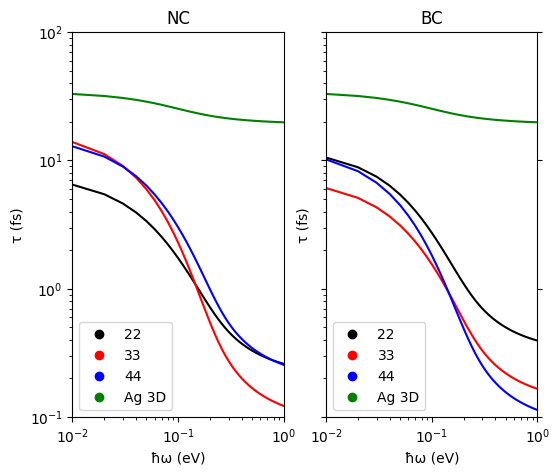

PyObject <matplotlib.legend.Legend object at 0x7f9b1a3b4640>

In [51]:
lab22 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black");
lab33 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red");
lab44 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="blue");
labAg = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="green");

figure(figsize=(6, 5))
subplot(1, 2, 1)
loglog(omegas, tau22nc, color="black")
loglog(omegas, tau33nc, color="red")
loglog(omegas, tau44nc, color="blue")
loglog(omegas, tauAg, color="green")
legend(handles = [lab22, lab33, lab44, labAg], labels = ["22", "33", "44", "Ag 3D"])
xlabel("ħω (eV)")
ylabel("τ (fs)")

xlim(0.01, 1)
ylim(0.1, 100)
xlim(0.01, 1)
title("NC")

subplot(1, 2, 2)

loglog(omegas, tau22bc, color="black")
loglog(omegas, tau33bc, color="red")
loglog(omegas, tau44bc, color="blue")
loglog(omegas, tauAg, color="green")
ylim(0.1, 100)
xlim(0.01, 1)
ylabel("τ (fs)")
yticks([0.1, 1, 10, 100], ["", "", "",""])
tick_params(right=true)
title("BC")
xlabel("ħω (eV)")
legend(handles = [lab22, lab33, lab44, labAg], labels = ["22", "33", "44", "Ag 3D"])


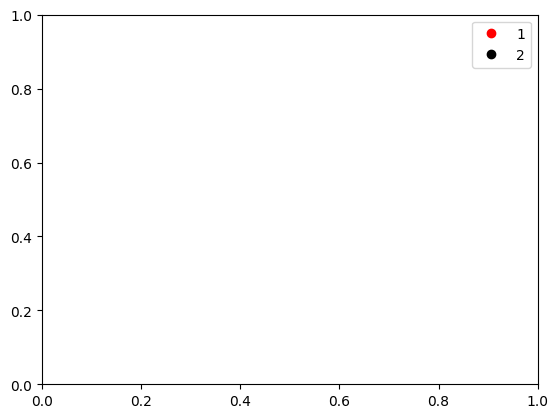

PyObject <matplotlib.legend.Legend object at 0x7fcdf4bfec40>

In [85]:
a = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red", label="1");
b = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black", label="2");

legend(handles = [a, b])

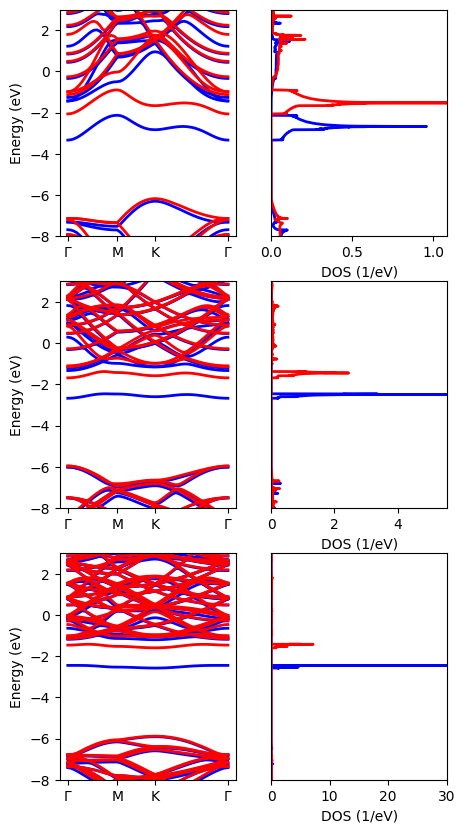

Total number of electrons in range: 0.8049954277581495


In [75]:
figure(figsize=(5, 10))
bandsoverlayedDOS2(bn22bc_dir*"/OrbProjDOS/BN22BC.dosUp", bn22bc_dir*"/OrbProjDOS/BN22BC.dosDn", bn22bc_dir*"/BN22BC.bands.eigenvals"
,(-8, 3), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2], dos_yticks=false)

bandsoverlayedDOS2(bn33bc_dir*"/OrbProjDOS/BN33BC.dosUp", bn33bc_dir*"/OrbProjDOS/BN33BC.dosDn", bn33bc_dir*"/BN33BC.bands.eigenvals"
,(-8, 3), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4], dos_yticks=false)

bandsoverlayedDOS2(bn44bc_dir*"/OrbProjDOS/BN44BC.dosUp", bn44bc_dir*"/OrbProjDOS/BN44BC.dosDn", bn44bc_dir*"/BN44BC.bands.eigenvals"
,(-8, 3), color_up = "blue", color_dn="red", return_tot=true, linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)

savefig("BNxxBC-OrbProjDOS.pdf")

Total number of electrons in range: 1.4159619896432165
Total number of electrons in range: 1.4188284262618405


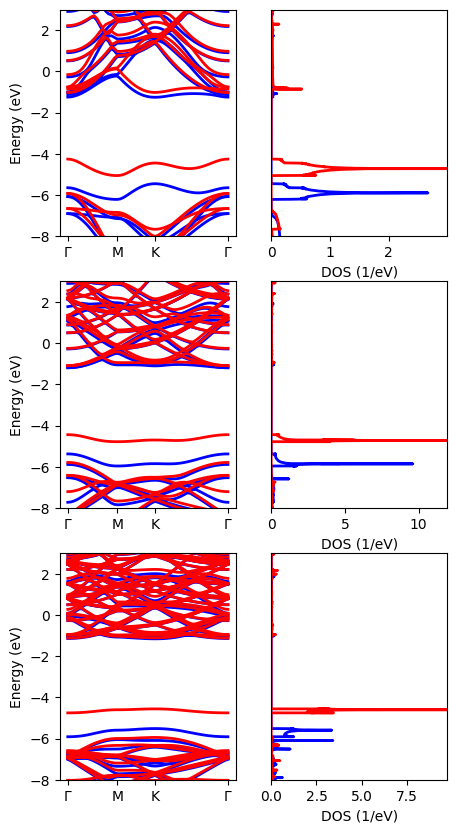

Total number of electrons in range: 1.4191349337763837


In [76]:
figure(figsize=(5, 10))
bandsoverlayedDOS2(bn22nc_dir*"/OrbProjDOS/BN22NC.dosUp", bn22nc_dir*"/OrbProjDOS/BN22NC.dosDn", bn22nc_dir*"/BN22NC.bands.eigenvals"
,(-8, 3), color_up = "blue", color_dn="red", linewidth=2, return_tot = true, band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2], dos_yticks=false)

bandsoverlayedDOS2(bn33nc_dir*"/OrbProjDOS/BN33NC.dosUp", bn33nc_dir*"/OrbProjDOS/BN33NC.dosDn", bn33nc_dir*"/BN33NC.bands.eigenvals"
,(-8, 3), color_up = "blue", return_tot=true, color_dn="red", linewidth=2, band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4], dos_yticks=false)


bandsoverlayedDOS2(bn44nc_dir*"/OrbProjDOS/BN44NC.dosUp", bn44nc_dir*"/OrbProjDOS/BN44NC.dosDn", bn44nc_dir*"/BN44NC.bands.eigenvals"
,(-8, 3), color_up = "blue", color_dn="red", return_tot=true, linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)
savefig("BNxxNC-OrbProjDOS.pdf")

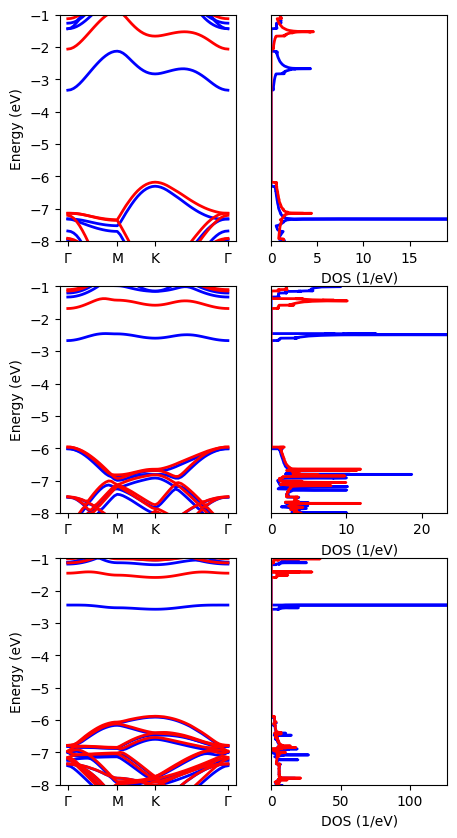

In [10]:
figure(figsize=(5, 10))
bandsoverlayedDOS2(bn22bc_dir*"/DOS/BN22BC.dosUp", bn22bc_dir*"/DOS/BN22BC.dosDn", bn22bc_dir*"/BN22BC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2], dos_yticks=false)

bandsoverlayedDOS2(bn33bc_dir*"/DOS/BN33BC.dosUp", bn33bc_dir*"/DOS/BN33BC.dosDn", bn33bc_dir*"/BN33BC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4], dos_yticks=false)

bandsoverlayedDOS2(bn44bc_dir*"/DOS/BN44BC.dosUp", bn44bc_dir*"/DOS/BN44BC.dosDn", bn44bc_dir*"/BN44BC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)
#savefig("BNxxBC-Bands.svg")
savefig("BNxxBC-Bands.pdf")

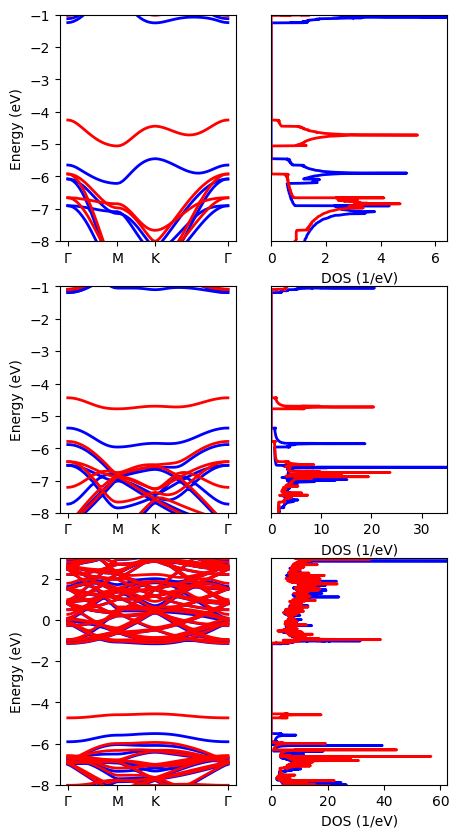

(-8.0, 3.0)

In [72]:
figure(figsize=(5, 10))
bandsoverlayedDOS2(bn22nc_dir*"/DOS/BN22NC.dosUp", bn22nc_dir*"/DOS/BN22NC.dosDn", bn22nc_dir*"/BN22NC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2], dos_yticks=false)

bandsoverlayedDOS2(bn33nc_dir*"/DOS/BN33NC.dosUp", bn33nc_dir*"/DOS/BN33NC.dosDn", bn33nc_dir*"/BN33NC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4], dos_yticks=false)

bandsoverlayedDOS2(bn44nc_dir*"/DOS/BN44NC.dosUp", bn44nc_dir*"/DOS/BN44NC.dosDn", bn44nc_dir*"/BN44NC.bands.eigenvals"
,(-8, 3), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)
#savefig("BNxxNC-Bands.pdf")

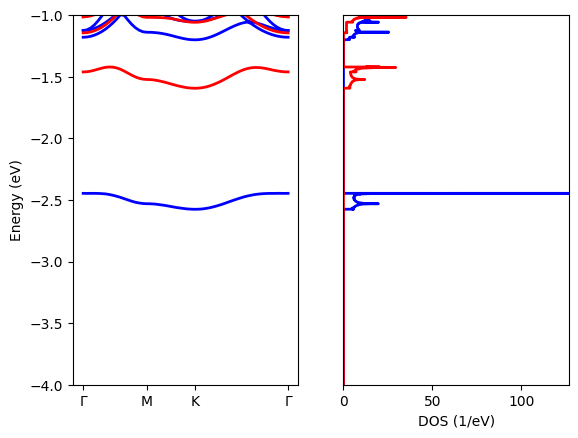

Total number of electrons in range: 4.310849823763105


(-4.0, -1.0)

In [75]:
bandsoverlayedDOS2(bn44bc_dir*"/DOS/BN44BC.dosUp", bn44bc_dir*"/DOS/BN44BC.dosDn", bn44bc_dir*"/BN44BC.bands.eigenvals"
,(-4, -1), return_tot=true, color_up = "blue", color_dn="red", linewidth=2, band_subplot=[1, 2, 1], dos_subplot=[1, 2, 2], dos_yticks=false)


In [10]:
Energies22=zeros(100)
Magnetizations22=zeros(100)
for i in 1:100
    Magnetizations22[i] = get_mag("$bn22bc_dir/magnetization/BN22BC-$i.out")
    Energies22[i] = list_energy("$bn22bc_dir/magnetization/BN22BC-$i.out")
end

In [11]:
Energies33=zeros(100)
Magnetizations33=zeros(100)
for i in 1:100
    #println(i)
    try
    Magnetizations33[i] = get_mag("$bn33bc_dir/magnetization/BN33BC-$i.out")
    Energies33[i] = list_energy("$bn33bc_dir/magnetization/BN33BC-$i.out")
    catch
    end
end

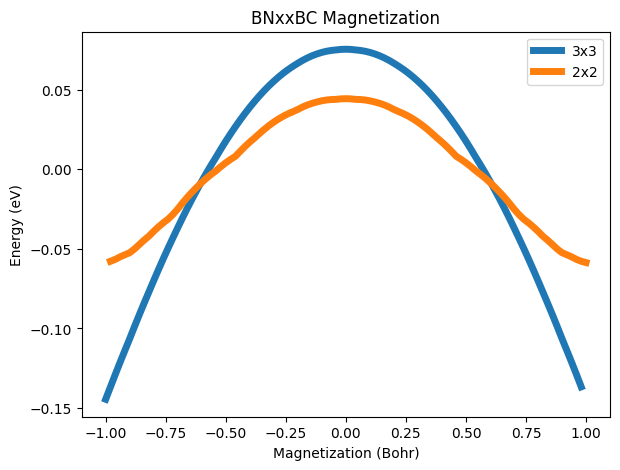

PyObject Text(0.5, 24.0, 'Magnetization (Bohr)')

In [17]:
figure(figsize=(15, 5))
subplot(1, 2, 1)
plot(Magnetizations33, Energies33 .-  mean(Energies33), linewidth=5, label="3x3")
title("BN33BC Magnetization")
ylabel("Energy (eV)")
title("BN33BC Magnetization")
xlabel("Magnetization (Bohr)")
#subplot(1, 2, 2)
plot(Magnetizations22, Energies22 .- mean(Energies22), linewidth=5, label="2x2")
ylabel("Energy (eV)")
title("BNxxBC Magnetization")
legend()
xlabel("Magnetization (Bohr)")

In [25]:
force_matrix, cell_map = phonon_force_matrix("$bn22bc_dir/phonon");
phonon_bands_bn22bc = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn22bc_buckled_dir/phonon");
phonon_bands_bn22bc_buckled = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.
Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.


In [1]:
pwd()

"/home2/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects"

In [7]:
force_matrix, cell_map = phonon_force_matrix("$bn22nc_dir/phonon");
phonon_bands_bn22nc = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.


In [19]:
force_matrix, cell_map = phonon_force_matrix("$bn33nc_dir/phonon");
phonon_bands_bn33nc = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 54
If this is incorrect, something went wrong somewhere at some point.


In [33]:
force_matrix, cell_map = phonon_force_matrix("$bn33bc_dir/phonon");
phonon_bands_bn33bc = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn33bc_buckled_dir/phonon");
phonon_bands_bn33bc_buckled = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 54
If this is incorrect, something went wrong somewhere at some point.
Number of phonon modes is: 54
If this is incorrect, something went wrong somewhere at some point.


In [31]:
force_matrix, cell_map = phonon_force_matrix("$bn44bc_dir/phonon");
phonon_bands_bn44bc = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn44bc_buckled_dir/phonon");
phonon_bands_bn44bc_buckled = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 96
If this is incorrect, something went wrong somewhere at some point.
Number of phonon modes is: 96
If this is incorrect, something went wrong somewhere at some point.


In [22]:
force_matrix, cell_map = phonon_force_matrix("$bn44nc_dir/phonon");
phonon_bands_bn44nc = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 96
If this is incorrect, something went wrong somewhere at some point.


In [22]:
sum(abs.(phonon_dispersionmodes(force_matrix, cell_map, [2/3, -1/3, 0])[2][:, 1]).^2)

0.9999999999999997

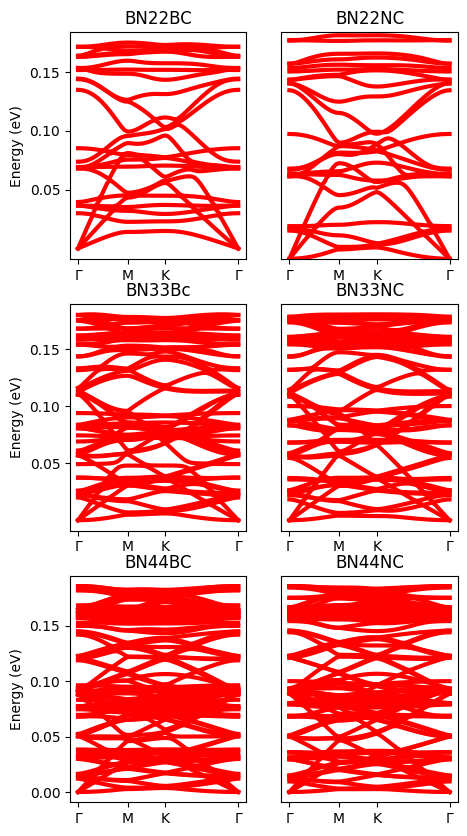

In [21]:
figure(figsize=(5, 10))
#suptitle("Phonon Bands ")

subplot(3, 2, 1)
plot(phonon_bands_bn22bc_buckled, linewidth=3, color="red")
label_plots()
title("BN22BC")
#ylim(0, 0.18)
yticks([0.05,  0.1, 0.15])
ylabel("Energy (eV)")

subplot(3, 2, 2)
plot(phonon_bands_bn22nc, linewidth=3, color="red")
title("BN22NC")
ylim(0, 0.18)
yticks(Float64[])
label_plots()

subplot(3, 2, 3)
plot(phonon_bands_bn33bc_buckled, linewidth=3, color="red")
title("BN33Bc")
label_plots()
yticks([0.05,  0.1, 0.15])
ylabel("Energy (eV)")

subplot(3, 2, 4)
title("BN33NC")
plot(phonon_bands_bn33nc, linewidth=3, color="red")
yticks(Float64[])
label_plots()


subplot(3, 2, 5)
title("BN44BC")
plot(phonon_bands_bn44bc_buckled, linewidth=3, color="red")
label_plots()
ylabel("Energy (eV)")

subplot(3, 2, 6)
title("BN44NC")
plot(phonon_bands_bn44nc, linewidth=3, color="red")
yticks(Float64[])
label_plots()

savefig("Phonon-Bands.pdf")
#ylim(0, 0.2)

Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.
24.00000000000055
Number of phonon modes is: 54
If this is incorrect, something went wrong somewhere at some point.
54.00000000000216
Number of phonon modes is: 96
If this is incorrect, something went wrong somewhere at some point.


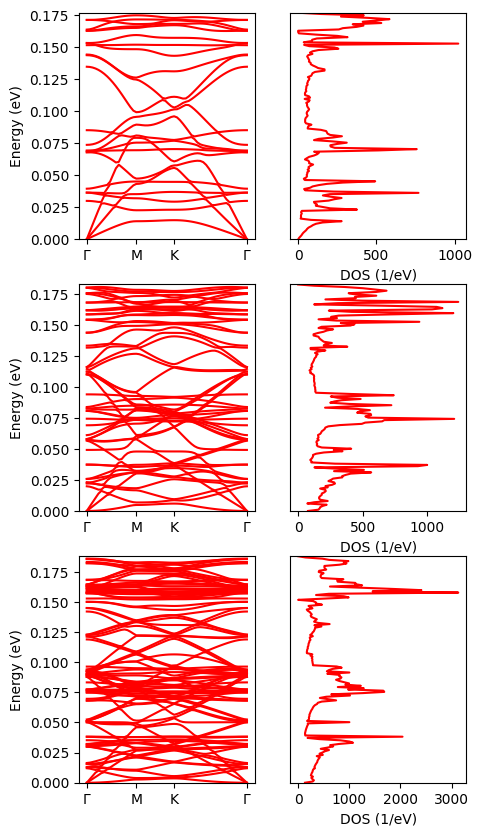

96.00000000000026


In [29]:
figure(figsize=(5, 10))
force_matrix, cell_map = phonon_force_matrix("$bn22bc_buckled_dir/phonon");
phononbandsoverlayedDOS(force_matrix, cell_map, mesh=100, histogram_width=1000, return_tot=true, color="red", band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2])

force_matrix, cell_map = phonon_force_matrix("$bn33bc_buckled_dir/phonon");
phononbandsoverlayedDOS(force_matrix, cell_map, mesh=100, histogram_width=1000, return_tot=true, color="red", band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4])
force_matrix, cell_map = phonon_force_matrix("$bn44bc_buckled_dir/phonon");
phononbandsoverlayedDOS(force_matrix, cell_map, mesh=100, histogram_width=1000, return_tot=true, color="red", band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6])

savefig("")

In [14]:
force_matrix, cell_map = phonon_force_matrix("$bn44bc_dir/phonon");


Number of phonon modes is: 96
If this is incorrect, something went wrong somewhere at some point.


In [17]:
phonon_dispersionmodes(force_matrix, cell_map, [0, 0.6, 0])[2][:, 1]

96-element Vector{ComplexF64}:
   4.130547609057382e-15 + 0.0im
  -1.368898562593145e-14 - 3.670211284483795e-15im
      0.9248168325315139 - 0.2519292584982567im
    8.12951719712128e-17 + 2.0712789210291158e-15im
 -2.1528409614827082e-14 - 1.7112392798323319e-15im
    -0.05461356435112528 + 0.013400215403710596im
   6.496340463860223e-15 - 1.034590117754036e-15im
  -2.968656372415986e-14 + 8.707705184352482e-16im
    -0.06408683188131178 + 0.018042885124282176im
   6.539758947225321e-16 + 7.082368544070472e-16im
 -2.0568197851746843e-14 + 5.395813971847339e-15im
    0.059425589019838104 + 0.02398547407578118im
  -4.929243078110989e-15 - 3.3805671514730965e-15im
                         ⋮
   8.490361388617131e-15 - 1.7662557539748402e-15im
  -9.125189135910792e-15 - 4.970301051517253e-15im
    -0.07065242221988205 + 0.019860491576546915im
   3.079321045802968e-15 - 1.9306584286893324e-16im
 -1.5670255085417524e-14 - 1.6301772455246902e-15im
     0.02185272116828359 - 0.007410680195420

In [5]:
phonon_bands = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

In [73]:
phonon_bands_buckled = phonon_dispersionpath(force_matrix_buckled, cell_map_buckled, kpointsfile="bandstruct.kpoints", return_negative=true);

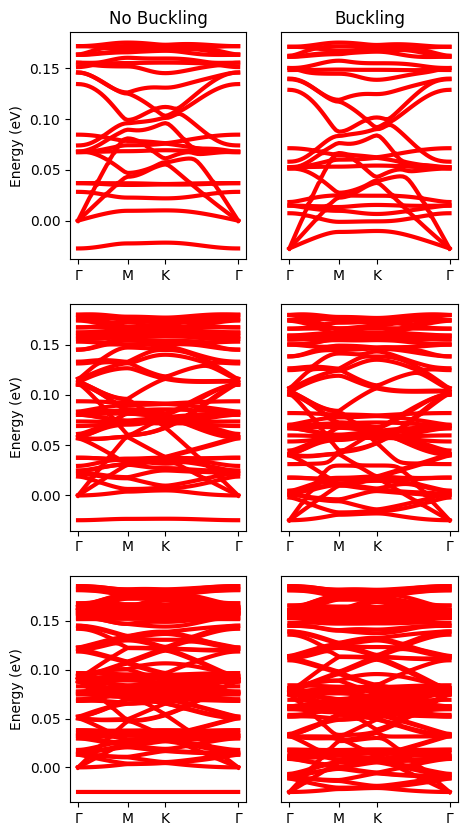

In [28]:
figure(figsize=(5, 10))
subplot(3, 2, 1)
plot(phonon_bands_bn22bc, linewidth=3, color="red")
label_plots()
ylabel("Energy (eV)")
title("No Buckling")
#ylim(-0.03, 0.1)
subplot(3, 2, 2)
plot(phonon_bands_bn22bc_buckled, linewidth=3, color="red")
label_plots()
title("Buckling")
#ylim(-0.03, 0.1)
yticks(Float64[])


subplot(3, 2, 3)
plot(phonon_bands_bn33bc, linewidth=3, color="red")
label_plots()
ylabel("Energy (eV)")
#title("No Buckling")
#ylim(-0.03, 0.1)
subplot(3, 2, 4)
plot(phonon_bands_bn33bc_buckled, linewidth=3, color="red")
label_plots()
#title("Buckling")
#ylim(-0.03, 0.1)
yticks(Float64[])


subplot(3, 2, 5)
plot(phonon_bands_bn44bc, linewidth=3, color="red")
label_plots()
ylabel("Energy (eV)")
#title("No Buckling")
#ylim(-0.03, 0.1)
subplot(3, 2, 6)
plot(phonon_bands_bn44bc_buckled, linewidth=3, color="red")
label_plots()
yticks(Float64[])
#title("Buckling")
savefig("Buckling-Phonons.pdf")

In [43]:
[p[1] for p in phonon_dispersion.(Ref(force_matrix), Ref(cell_map), [q  for q in [k ./ 100 *i for i in 1:100]] , return_negative=true)*eV]

100-element Vector{Float64}:
 -0.0010052070642324227
 -0.0010052070642186113
 -0.0010052070641955984
 -0.0010052070641633857
 -0.0010052070641219622
 -0.0010052070640713358
 -0.0010052070640114948
 -0.0010052070639424602
 -0.0010052070638642135
 -0.0010052070637767622
 -0.0010052070636801026
 -0.0010052070635742445
 -0.0010052070634591758
  ⋮
 -0.001005207027779312
 -0.001005207026955433
 -0.001005207026122351
 -0.0010052070252800633
 -0.0010052070244285663
 -0.0010052070235678767
 -0.0010052070226979671
 -0.0010052070218188615
 -0.001005207020930538
 -0.0010052070200330244
 -0.0010052070191262964
 -0.0010052070182103752

In [55]:
phonon_dispersion(force_matrix, cell_map, [0, 0, 0], return_negative=true)

24-element Vector{Float64}:
 -0.027353091507779658
 -2.7548140271950296e-9
  1.192205469443938e-9
  2.840727159445403e-9
  0.02830012431393632
  0.03689346577838627
  0.036893465778386376
  0.06736950578652433
  0.06736950578652438
  0.06796372752641981
  0.06796372752641998
  0.07396211213039897
  0.08454737262219467
  0.1342849153744948
  0.1456788903194319
  0.14567889031943193
  0.15102265364038214
  0.15530589619537563
  0.15530589619537571
  0.16317930900675218
  0.1631793090067522
  0.16339725915708697
  0.1716007337040448
  0.17160073370404494

In [80]:
abs.(phonon_dispersionmodes(force_matrix_buckled, cell_map_buckled, [0, 0, 0])[2][:, 7])

24-element Vector{Float64}:
 0.00015504930216639438
 0.002802882224382881
 0.9255270925440272
 0.0003495030103355054
 0.004836314109344728
 0.1379024196635248
 0.0031672942674610643
 0.002270892646174503
 0.15038334747894314
 0.00014260674065921732
 0.0012529765033123246
 0.009449834139348386
 0.003552012945569296
 0.0024287089574255606
 0.15143030238869845
 0.0009332577006218294
 0.0003585842907014526
 0.15953067723244793
 0.00014934703490241275
 0.0008190463958557383
 0.16442194736219276
 0.001123795426297939
 0.0005061348118337387
 0.16184073759367903

In [26]:
zero_es = JJDFTX.dos_properties(bn22nc_dir*"/DOS/BN22NC.dosDn")

14-element Vector{Float64}:
 -22.951128379296446
 -21.971875229437302
 -21.87419129146996
 -20.49719452412246
 -16.575112494698445
 -15.676230458819449
 -14.579751527333842
  -8.88618040195684
  -8.882253403094866
  -5.9232311101475155
  -5.05639596794743
  -4.2546631724811705
  -1.0233503603204808
   5.834281998779124

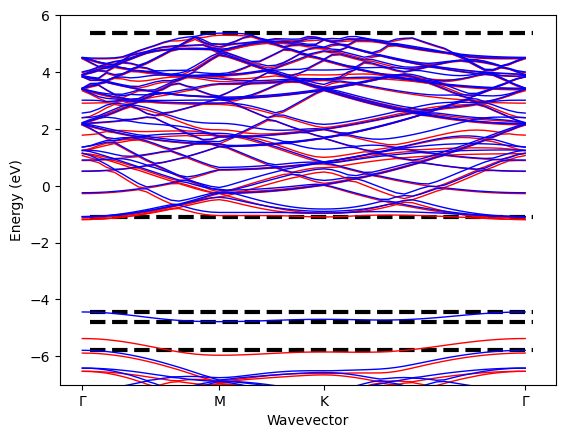

PyObject <matplotlib.collections.LineCollection object at 0x7f247c512850>

In [90]:
plot_bands("$bn33nc_dir/BN33NC.bands.eigenvals", spin=2, to_greek=true, color_dn = "blue", color_up = "red", linewidth=1)
ylim(-7, 6)
hlines(zero_es, 1, 56, linewidth=3, linestyle="dashed", color="black")

In [56]:
Heph, celleph_map = hephwannier(bn22bc_dir*"/Plasmons/wannierUp", 1), np.loadtxt(bn22bc_dir*"/Plasmons/wannierUp.mapeph.txt");
Pwannier = pwannier(bn22bc_dir*"/Plasmons/momentumUp.txt", bn22bc_dir*"/Plasmons/wannierUp.map.txt");
Hwannier, cell_map = hwannier(bn22bc_dir*"/Plasmons/wannierUp"), np.loadtxt(bn22bc_dir*"/Plasmons/wannierUp.map.txt")
force_matrix, cellph_map = phonon_force_matrix(bn22bc_dir*"/Plasmons/../../BN22BC_Buckled/phonon");

In [57]:
subsampling = returnfermikpoint(Hwannier, cell_map, -2.65, Val(2), mesh=10, num_blocks=100)

(Real[0.23476733251614124 0.2700367472130407 … 0.3890392427625591 0.8030759332169684; 0.2334293099807223 0.5299958462592953 … 0.41390588293676234 0.7467546511743615; 0.0 0.0 … 0.0 0.0], 0.2189)

In [29]:
JJDFTX.dosatmu(Hwannier, cell_map, -2.65, mesh=20, num_blocks=1000)

2.214

In [58]:
tauBN22BC =  τ(HwannierUp, cellmapUp, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), -2.65, Val(2); histogram_width=100, mesh=20, supplysampling=subsampling, supplydos=2, dos_num_blocks=1000, num_blocks=10, dosmesh=20, fracroom=1)

DOS at Fermi Energy is: 2
Sampling from 2189kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


100-element Vector{Float64}:
 3.399015331548072
 3.1552248032641983
 2.9209236358864983
 2.6984659011806698
 2.4895875295553656
 2.2953886571832594
 2.1163784711355658
 1.9525633736852257
 1.80355668507604
 1.6686906930689134
 1.5471174179749765
 1.4378907149724958
 1.3400276606625345
 ⋮
 0.4656538322932312
 0.46488706912002536
 0.46413959648256087
 0.46341069544590335
 0.4626996823618664
 0.46200590673032604
 0.4613287492142184
 0.460667619795492
 0.4600219560604711
 0.45939122160415924
 0.4587749045439661
 0.4581725161342033

In [45]:
export_heph("$bn44nc_dir/Plasmons/wannier", 3*2*16, [1, 1, 1], spin=Val('d'));
export_momentum("$bn44nc_dir/Plasmons/wannier", [12, 12, 1], spin=Val('d'));

In [47]:
Heph, celleph_map = hephwannier(bn44nc_dir*"/Plasmons/wannierDn", 1), np.loadtxt(bn44nc_dir*"/Plasmons/wannierDn.mapeph.txt");
Pwannier = pwannier(bn44nc_dir*"/Plasmons/momentumDn.txt", bn22bc_dir*"/Plasmons/wannierDn.map.txt");
Hwannier, cell_map = hwannier(bn44nc_dir*"/Plasmons/wannierDn"), np.loadtxt(bn44nc_dir*"/Plasmons/wannierDn.map.txt")
force_matrix, cellph_map = phonon_force_matrix(bn44nc_dir*"/Plasmons/../../BN44NC/phonon");

In [49]:
JJDFTX.dosatmu(Hwannier, cell_map, -4.633, mesh=20, num_blocks=1000)

5.21175

In [52]:
subsampling = returnfermikpoint(Hwannier, cell_map, -4.633, Val(2), mesh=20, num_blocks=100)

(Real[0.6563404943554563 0.8783101816077592 … 0.6210220000602222 0.8351471877319543; 0.48318320781910895 0.5735860323159159 … 0.5141567478860809 0.4837808850703591; 0.0 0.0 … 0.0 0.0], 0.6134000000000001)

In [55]:
tauBN44NC =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), -4.633, Val(2); histogram_width=100, mesh=10, supplysampling=subsampling, supplydos=5.2, dos_num_blocks=1000, num_blocks=10, dosmesh=20, fracroom=1)

DOS at Fermi Energy is: 5.2
Sampling from 24536kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


100-element Vector{Float64}:
 1.5915113950103372
 1.4918486364141545
 1.3942305443449539
 1.2996994732655587
 1.209109073881248
 1.1230979669657941
 1.0420877333658778
 0.9663014299383437
 0.8957963288743968
 0.8305036770242038
 0.7702687491922862
 0.7148859107604112
 0.6641253739266347
 ⋮
 0.18109729948728168
 0.18073442238927676
 0.1803809245134937
 0.18003644686465323
 0.1797006485376799
 0.17937320559239467
 0.1790538100111758
 0.17874216873253676
 0.17843800275424962
 0.1781410463002421
 0.17785104604604174
 0.17756776039802133

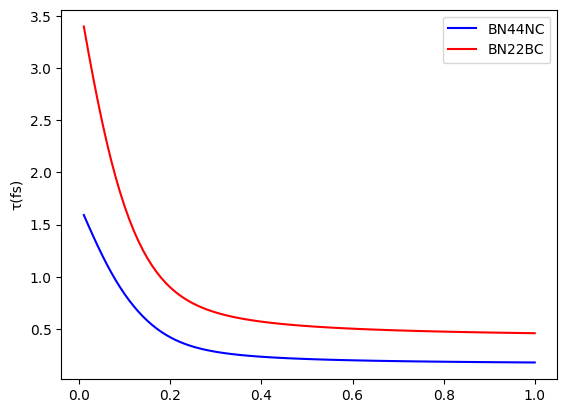

In [66]:
plot(0.01:0.01:1, tauBN44NC, color="blue", label="BN44NC")
plot(0.01:0.01:1, tauBN22BC, color="red", label="BN22BC")
ylabel("τ(fs)")
legend()
savefig("DecayTime.pdf")

In [90]:
JJDFTX.make_mesh(Int(ceil(2*3^(1/3))), Val(3))

27×3 Matrix{Float64}:
 0.0       0.0       0.0
 0.0       0.0       0.333333
 0.0       0.0       0.666667
 0.0       0.333333  0.0
 0.0       0.333333  0.333333
 0.0       0.333333  0.666667
 0.0       0.666667  0.0
 0.0       0.666667  0.333333
 0.0       0.666667  0.666667
 0.333333  0.0       0.0
 0.333333  0.0       0.333333
 0.333333  0.0       0.666667
 0.333333  0.333333  0.0
 ⋮                   
 0.333333  0.666667  0.0
 0.333333  0.666667  0.333333
 0.333333  0.666667  0.666667
 0.666667  0.0       0.0
 0.666667  0.0       0.333333
 0.666667  0.0       0.666667
 0.666667  0.333333  0.0
 0.666667  0.333333  0.333333
 0.666667  0.333333  0.666667
 0.666667  0.666667  0.0
 0.666667  0.666667  0.333333
 0.666667  0.666667  0.666667

In [81]:
ceil(2*3^1/3)

2.0

In [89]:
ceil(2*3^(1/3))

3.0